In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [10]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
df = pd.read_csv('data/Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
df.shape

(167, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
df.duplicated().sum()

0

In [6]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


# **Data Visualisation**

### **a) Income**

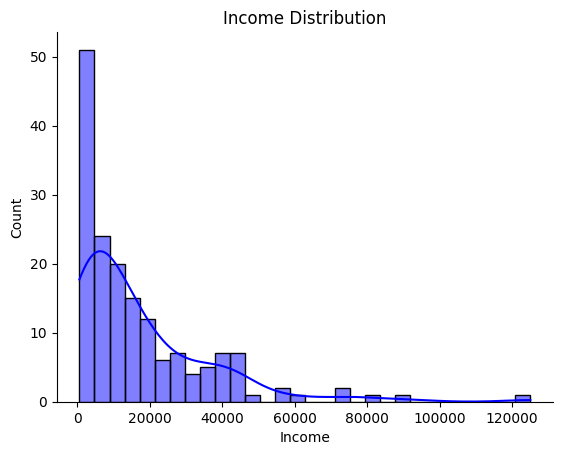

In [7]:
sns.histplot(data=df, x='income', kde=True, bins=30, color='blue')
plt.title('Income Distribution')
plt.xlabel('Income')
sns.despine()
plt.show()

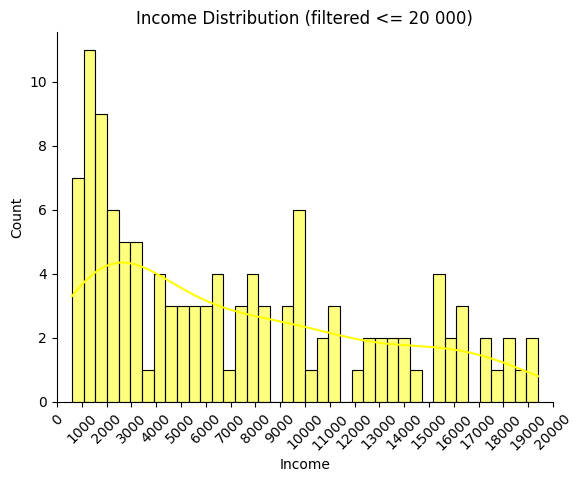

In [8]:
df_filtered = df[df['income'] <= 20000]

sns.histplot(data=df_filtered, x='income', kde=True, bins=40, color='yellow')
plt.title('Income Distribution (filtered <= 20 000)')
plt.xlabel('Income')
plt.xticks(range(0,21000,1000), rotation=45)
plt.xlim(0,20000)
sns.despine()
plt.show()

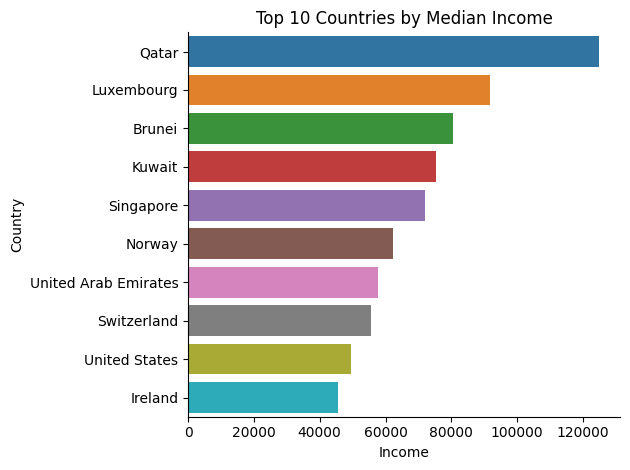

In [14]:
top_countries = df.groupby('country')['income'].median().sort_values(ascending=False).head(10)
df_top = df[df['country'].isin(top_countries.index)]

sns.barplot(data=df_top, y='country', x='income', order=top_countries.index, ci=None, palette=sns.color_palette('tab10', n_colors=10))
plt.title('Top 10 Countries by Median Income')
plt.ylabel('Country')
plt.xlabel('Income')
plt.tight_layout()
sns.despine()
plt.show()

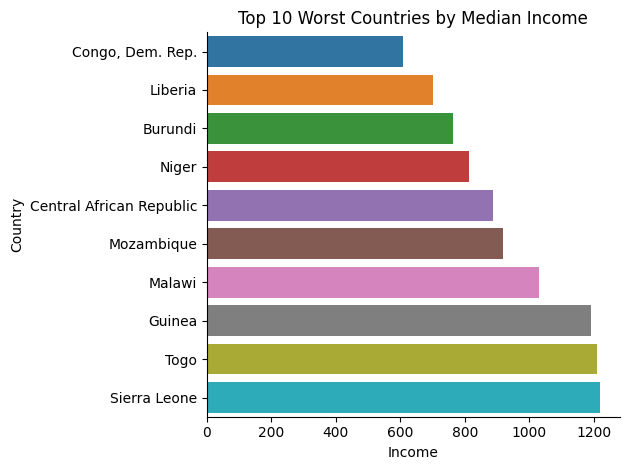

In [17]:
worst_countries = df.groupby('country')['income'].median().sort_values(ascending=True).head(10)
df_worst = df[df['country'].isin(worst_countries.index)]

sns.barplot(data=df_worst, x='income', y='country', ci=None, order=worst_countries.index, palette=sns.color_palette('tab10', n_colors=10))
plt.title('Top 10 Worst Countries by Median Income')
plt.xlabel('Income')
plt.ylabel('Country')
plt.tight_layout()
sns.despine()
plt.show()

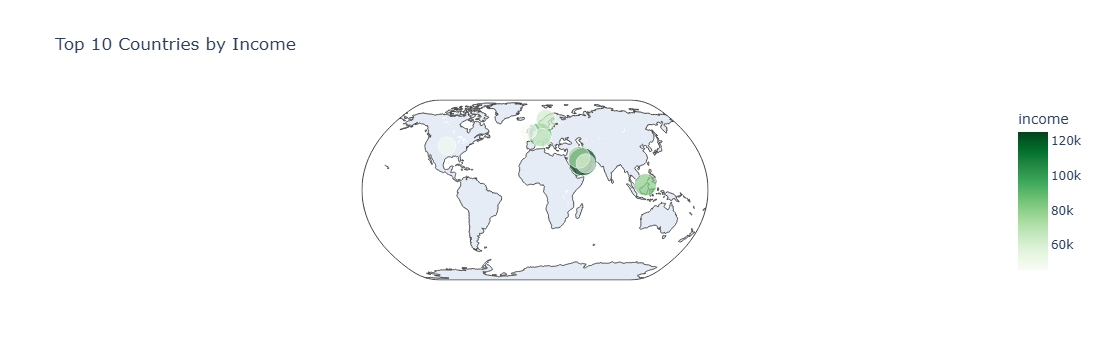

In [46]:
import plotly.express as px

top10 = df.nlargest(10, 'income')
fig = px.scatter_geo(top10, locations='country', locationmode='country names',
                     size='income', color='income', color_continuous_scale='Greens',
                     hover_name='country',
                     projection='natural earth', title='Top 10 Countries by Income')
fig.show()

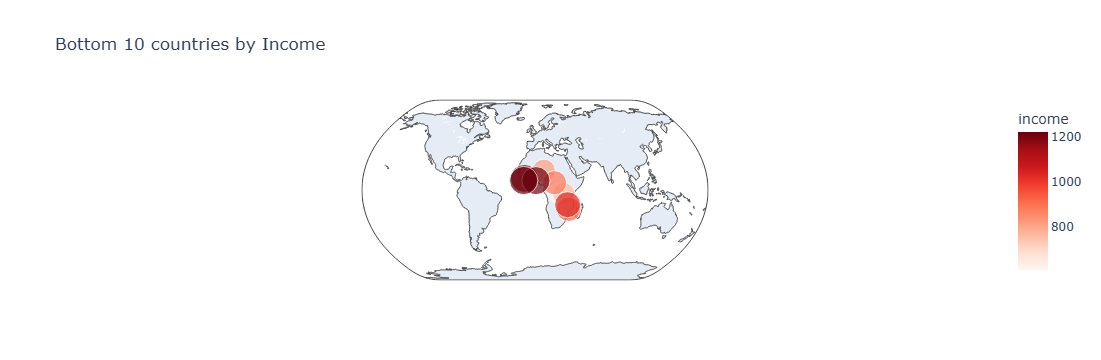

In [45]:
bottom10 = df.nsmallest(10, 'income')

fig= px.scatter_geo(bottom10, locations='country', locationmode='country names',
                    size='income', color='income', color_continuous_scale='Reds',
                    hover_name='country', projection='natural earth', title='Bottom 10 countries by Income')
fig.show()

To be continued.